<a href="https://colab.research.google.com/github/DouglasLeite77/mecaniQA-MACAPA/blob/main/baseline_metricas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# 1. Leitura e Preparação dos Dados
caminho_arquivo = './datasets/mecaniqa_dataset.xlsx'

# Caso esteja rodando no Colab e o arquivo não esteja mapeado, pede o upload
if not os.path.exists(caminho_arquivo) and not os.path.exists('./mecaniqa_dataset.xlsx'):
    from google.colab import files
    print('Faça o upload da planilha mecaniqa_dataset.xlsx')
    upload = files.upload()
    caminho_arquivo = list(upload.keys())[0]
elif os.path.exists('./mecaniqa_dataset.xlsx'):
    caminho_arquivo = './mecaniqa_dataset.xlsx'

df = pd.read_excel(caminho_arquivo)
df['Data'] = pd.to_datetime(df['Data'])
df = df.sort_values('Data').set_index('Data')

# Isola a primeira coluna numérica como nossa série alvo
serie_manutencoes = df.select_dtypes('number').iloc[:, 0].astype(float)

print('Dados carregados com sucesso! Total de registros:', len(serie_manutencoes))

Dados carregados com sucesso! Total de registros: 731


In [6]:
# 2. Funções de Baseline com Proteção contra Vazamento (Shift)

def modelo_naive(serie):
    """A previsão de hoje é o valor exato de ontem."""
    return serie.shift(1)

def modelo_media_movel(serie, janela=7):
    """A previsão de hoje é a média dos 'n' dias anteriores."""
    return serie.shift(1).rolling(window=janela).mean()

previsao_naive = modelo_naive(serie_manutencoes)
previsao_mm7 = modelo_media_movel(serie_manutencoes, janela=7)

print('Previsões de baseline calculadas e protegidas.')

Previsões de baseline calculadas e protegidas.


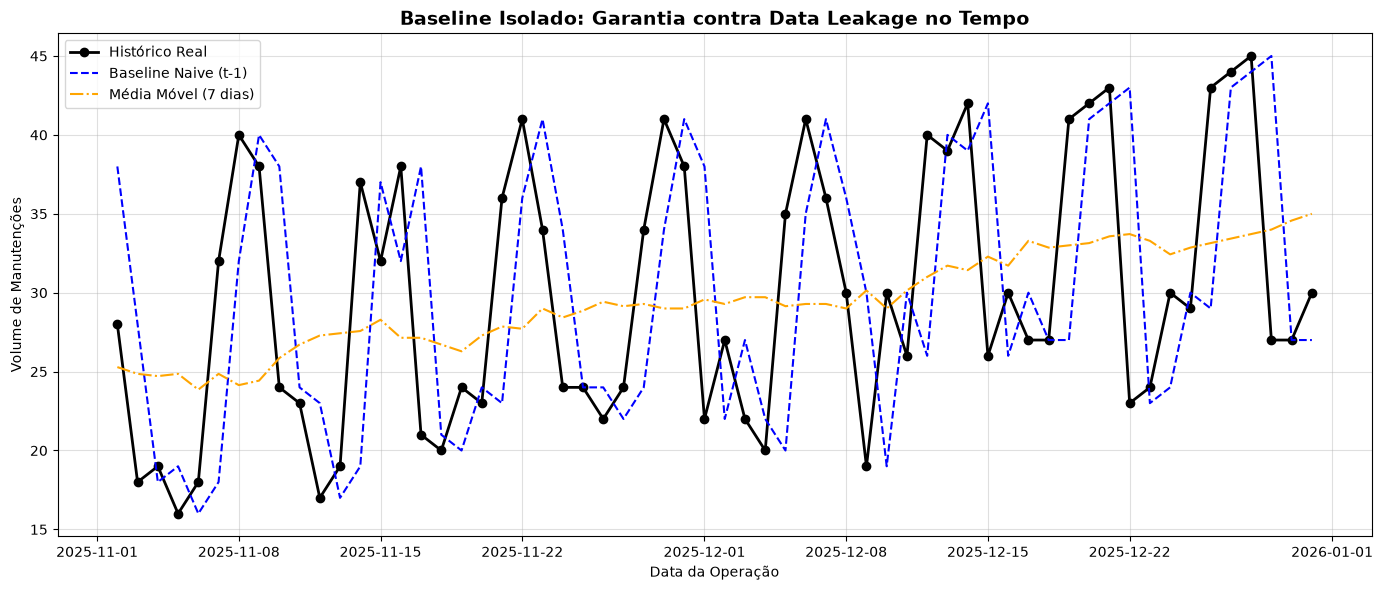

In [7]:
# 3. Validação Visual para QA (Critério de Aceite)
plt.figure(figsize=(14, 6))

# Filtro de zoom nos últimos 60 dias para visualizar o deslocamento temporal
dias_zoom = -60

plt.plot(serie_manutencoes[dias_zoom:], label='Histórico Real', color='black', linewidth=2, marker='o')
plt.plot(previsao_naive[dias_zoom:], label='Baseline Naive (t-1)', color='blue', linestyle='--')
plt.plot(previsao_mm7[dias_zoom:], label='Média Móvel (7 dias)', color='orange', linestyle='-.')

plt.title('Baseline Isolado: Garantia contra Data Leakage no Tempo', fontsize=14, fontweight='bold')
plt.xlabel('Data da Operação')
plt.ylabel('Volume de Manutenções')
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

In [8]:
coluna_alvo = serie_manutencoes.name if hasattr(serie_manutencoes, 'name') and serie_manutencoes.name else 'Volume_Manutencoes'
if coluna_alvo not in df.columns:
    df[coluna_alvo] = serie_manutencoes

# 1. Criação dos Lags (Defasagens temporais)
# lag_1: Persistência imediata (t-1)
# lag_7: Sazonalidade semanal (mesmo dia da semana anterior)
df['lag_1'] = df[coluna_alvo].shift(1)
df['lag_7'] = df[coluna_alvo].shift(7)

# 2. Rolling Window (Janela Rolante) sem Data Leakage
# shift(1) garante que o cálculo em 't' use apenas a média dos 7 dias anteriores (t-7 até t-1)
df['rolling_mean_7'] = df[coluna_alvo].shift(1).rolling(window=7).mean()

# (Opcional) Desvio padrão móvel dos 7 dias anteriores para volatilidade
df['rolling_std_7'] = df[coluna_alvo].shift(1).rolling(window=7).std()

# 3. Tratamento dos valores nulos gerados no topo
# O maior deslocamento foi de 7 períodos (lag_7 e rolling de 7 dias sobre shift 1 geram 7 NaNs no topo)
# Descartar as linhas com NaN decorrentes da inicialização das janelas:
df_features = df.dropna().copy()

In [9]:
print(f"Dimensões originais: {df.shape} | Após descarte dos NaNs de aquecimento: {df_features.shape}")
print(f"Valores nulos restantes no dataset: {df_features.isna().sum().sum()}\n")

df_features[[coluna_alvo, 'lag_1', 'lag_7', 'rolling_mean_7']].head(15)

Dimensões originais: (731, 6) | Após descarte dos NaNs de aquecimento: (708, 6)
Valores nulos restantes no dataset: 0



,Trocas_Oleo,lag_1,lag_7,rolling_mean_7
Data,,,,
2024-01-08,13.0,31.0,11.0,18.285714
2024-01-09,10.0,13.0,9.0,18.571429
2024-01-10,13.0,10.0,12.0,18.714286
2024-01-11,10.0,13.0,15.0,18.857143
2024-01-12,25.0,10.0,25.0,18.142857
2024-01-13,28.0,25.0,25.0,18.142857
2024-01-14,22.0,28.0,31.0,18.571429
2024-01-15,7.0,22.0,13.0,17.285714
2024-01-16,11.0,7.0,10.0,16.428571
